# Modelado Estocástico

## Modelos VAR (Vector Autoregressions)

En este notebook vamos a estimar modelos de vectores
autorregresivos (VAR) en Python.

Para comenzar, recordemos AR(1):
 $$AR(1):  u_t = \rho  \ u_{t-1} + \epsilon_t$$

Se trata de un modelo regresivo univariado, pero ¿Qué ocurre si queremos modelar varias variables conjuntamente?

$$y_t = m + A y_{t-1} + \epsilon_t$$

El modelo VAR es la generalización de los modelos autoregresivos univariados a múltiples variables temporales en forma de vector. Un VAR($p$) sería, por ejemplo:
$$
\mathbf y_t =
\mathbf m
+
A_1\mathbf y_{t-1}
+
A_2\mathbf y_{t-2}
+\cdots+
A_p\mathbf y_{t-p}
+
\boldsymbol\varepsilon_t.
$$


Si $p=1$, para $k = 2$ tendremos un VAR(1) bivariado

$$
\mathbf y_t =
\begin{pmatrix}
y_{1t}\\
y_{2t}
\end{pmatrix}
$$

y

$$
A =
\begin{pmatrix}
a_{11} & a_{12}\\
a_{21} & a_{22}
\end{pmatrix}.
$$

Por lo tanto,

$$y_{1t} = m_1 + a_{11} y_{1, t-1} + a_{12} y_{2 t-1} + \epsilon_{1t}$$
$$y_{2t} = m_2 + a_{21} y_{1, t-1} + a_{22} y_{2 t-1} + \epsilon_{2t}$$

Cada variable se expresa como una combinación lineal del rezago de sí
misma y del rezago de la otra variable.

### Construcción de un VAR

Consideremos el siguiente proceso:

$$
A =
\begin{pmatrix}
0.5 & 0.2\\
0.1 & 0.4
\end{pmatrix}
$$

y

$$
\mathbf m =
\begin{pmatrix}
1\\
0.5
\end{pmatrix}.
$$

Por lo tanto, el proceso generador de datos será:

$$y_{1t} = 1.0 + 0.5 y_{1, t-1} + 0.2 y_{2 t-1} + \epsilon_{1t}$$
$$y_{2t} = 0.5 + 0.1 y_{1, t-1} + 0.4 y_{2 t-1} + \epsilon_{2t}$$

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.var_model import VAR

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(2484)

Generamos $A$ y $m$:

In [ ]:
A = np.array([
    [0.5, 0.2],
    [0.1, 0.4]
])

m = np.array([1.0, 0.5])

#### Los $\varepsilon_t$ del VAR

Además de los parámetros $A$ y $\mathbf m$, debemos especificar las
propiedades del vector de términos de error $\varepsilon_t$.

Definimos

$$
\boldsymbol\varepsilon_t =
\begin{pmatrix}
\varepsilon_{1t}\\
\varepsilon_{2t}
\end{pmatrix}.
$$

Supondremos que

$$
E(\boldsymbol\varepsilon_t)=
\mathbf 0
$$

y que

$$
E(\boldsymbol\varepsilon_t
\boldsymbol\varepsilon_s')
=
\begin{cases}
\Omega & \text{si }t=s,\\
0 & \text{si }t\neq s.
\end{cases}
$$

La matriz $\Omega$ es la matriz de varianzas y covarianzas.

En este ejemplo elegimos:

$$
\Omega =
\begin{pmatrix}
1 & 0.5\\
0.5 & 1
\end{pmatrix}.
$$

Esta matriz es parte del proceso generador de datos: no se obtiene
de $A$ ni de $\mathbf m$.

En particular,

$$
Var(\varepsilon_{1t})=1,
\qquad
Var(\varepsilon_{2t})=1
$$

y

$$
Cov(\varepsilon_{1t},\varepsilon_{2t})=0.5.
$$

Por lo tanto, los $\varepsilon$ no están correlacionados a través del tiempo,
pero pueden estar correlacionados contemporáneamente.

In [ ]:
Omega = np.array([
    [1.0, 0.5],
    [0.5, 1.0]
])


#### Estabilidad del VAR

En el caso univariado AR(1),

$$
y_t = c + \rho y_{t-1} + \varepsilon_t,
$$

la condición de estacionariedad es

$$
|\rho|<1.
$$

En el VAR(1), el papel de $\rho$ lo cumplen los autovalores de la
matriz $A$.

El proceso será estable si:

$$
\boxed{
|\lambda_i|<1
\quad\text{para todo }i
}
$$

donde $\lambda_i$ son los autovalores de $A$.

Observamos los autovalores de A y sus módulos:

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Autovalores:")
print(eigenvalues)
print("Módulo de los autovalores:")
print(np.abs(eigenvalues))

Autovalores:
[0.6 0.3]
Módulo de los autovalores:
[0.6 0.3]


In [ ]:
stable = np.all(np.abs(eigenvalues) < 1)

print("¿El VAR es estable?", stable)

¿El VAR es estable? True


Para nuestro ejemplo, ambos autovalores tienen módulo menor que uno.

Por lo tanto, estamos en el **Caso 1**:

$$
|\lambda_1|<1
\qquad
|\lambda_2|<1.
$$

En este caso las variables son $I(0)$ y existe un equilibrio de largo
plazo.

### Caso 2:
$\lambda_1=1$ y $|\lambda_2|<1$

Consideremos ahora

$$
A =
\begin{pmatrix}
1.2 & -0.2\\
0.6 & 0.4
\end{pmatrix}.
$$

Los autovalores de esta matriz son

$$
\lambda_1=1,
\qquad
\lambda_2=0.6.
$$

Por lo tanto, estamos en el **Caso 2** de la clase.

In [ ]:
A_caso2 = np.array([
    [1.2, -0.2],
    [0.6, 0.4]
])

np.linalg.eigvals(A_caso2)

array([1. , 0.6])

En este caso uno de los autovalores es igual a uno y el otro tiene
módulo menor que uno.

Por lo tanto:

- una componente del sistema es $I(1)$;
- la otra es $I(0)$;
- las variables $y_{1t}$ e $y_{2t}$ son $I(1)$.

Este es el caso que posteriormente permite estudiar una relación de
cointegración.

### Caso 3:
$\lambda_1=\lambda_2=1$

Consideremos ahora una matriz $A\neq I$ cuyos dos autovalores son iguales a uno.


$$
A =
\begin{pmatrix}
0.8 & -0.4\\
0.1 & 1.2
\end{pmatrix}.
$$

Los autovalores son ambos iguales a uno.

In [ ]:
A_caso3 = np.array([
    [0.8, -0.4],
    [0.1, 1.2]
])

np.linalg.eigvals(A_caso3)

array([1., 1.])

Estamos en el **Caso 3**.

En este caso no podemos diagonalizar $A$ utilizando dos autovectores
linealmente independientes asociados al autovalor uno.

La clase analiza este caso utilizando la forma de Jordan.

En este notebook no desarrollaremos nuevamente la demostración, sino que
nos limitaremos a identificar el caso a partir de los autovalores.

### Simulación del proceso VAR(1) (CASO 1)

Retomamos el proceso original con los parámetros $A$, $m$ y $\Omega$ definidos.

Para generar observaciones necesitamos los
$\boldsymbol\varepsilon_t$.

Supondremos, para simplificar la simulación (no es un requisito suponer normalidad), que

$$
\boldsymbol\varepsilon_t
\sim N(\mathbf 0,\Omega).
$$

In [ ]:
T = 350

eps = np.random.multivariate_normal(
    mean=[0, 0],
    cov=Omega,
    size=T
)

Para generar el proceso utilizaremos recursivamente:

$$
\mathbf y_t =
\mathbf m
+
A\mathbf y_{t-1}
+
\boldsymbol\varepsilon_t.
$$

In [ ]:
y = np.zeros((T, 2))

for t in range(1, T):
    y[t] = m + A @ y[t-1] + eps[t]

In [ ]:
df = pd.DataFrame(
    y[1:],
    columns=["y1", "y2"]
)

df.head()

,y1,y2
0,1.384330,0.717086
1,0.927813,0.822939
2,0.767278,0.537168
3,0.597992,1.227459
4,1.469741,0.560313


###Las series simuladas

Visualicemos las dos variables del VAR.

Como el sistema es estable, esperamos que las series fluctúen alrededor
de un nivel de equilibrio de largo plazo.

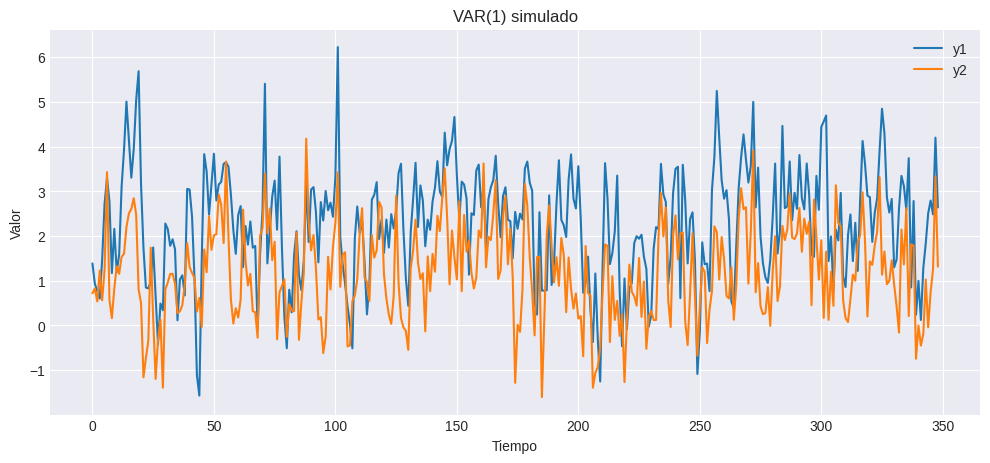

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

df.plot(ax=ax)

ax.set_title("VAR(1) simulado")
ax.set_xlabel("Tiempo")
ax.set_ylabel("Valor")

plt.show()

### Equilibrio de largo plazo (Caso 1)

En un VAR(1),

$$
\mathbf y_t =
\mathbf m+A\mathbf y_{t-1}
+\boldsymbol\varepsilon_t.
$$

Busquemos el equilibrio de largo plazo $\bar{\mathbf y}$. Si el proceso se encuentra en ese equilibrio, entonces:

$$
\bar{\mathbf y}
=
\mathbf m+A\bar{\mathbf y}.
$$

Reordenando:

$$
(I-A)\bar{\mathbf y}
=
\mathbf m.
$$

Por lo tanto, si $I-A$ es no singular,

$$
\boxed{
\bar{\mathbf y}
=
(I-A)^{-1}\mathbf m
}
$$

En lugar de calcular explícitamente la inversa, utilizaremos
`np.linalg.solve`.

In [ ]:
I = np.eye(2)

y_bar = np.linalg.solve(
    I - A,
    m
)

print("Equilibrio de largo plazo:")
print(y_bar)

Equilibrio de largo plazo:
[2.5  1.25]


Podemos verificar que el resultado satisface

$$
(I-A)\bar{\mathbf y}=\mathbf m.
$$

In [ ]:
(I - A) @ y_bar

array([1. , 0.5])

### Estimación de un VAR

En el ejemplo hasta acá, los parámetros eran conocidos porque construimos el proceso, pero en la práctica nuestro objetivo será estimarlos a partir de datos empíricos de variables que estemos relacionando.

In [ ]:
model = VAR(df)

`VAR` recibe un `DataFrame` cuyas columnas representan las
variables del sistema.

- `y1` es la primera variable;
- `y2` es la segunda variable.

In [ ]:
results = model.fit(1)

print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 15, Aug, 2026
Time:                     15:42:15
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  -0.255467
Nobs:                     348.000    HQIC:                 -0.295442
Log likelihood:          -925.573    FPE:                   0.724783
AIC:                    -0.321884    Det(Omega_mle):        0.712446
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.957819         0.111907            8.559           0.000
L1.y1         0.453453         0.053275            8.512           0.000
L1.y2         0.239507         0.062831            3.812           0.000

Results for equation 

#### Matriz de coeficientes

En un VAR(1), `results.coefs[0]` contiene la matriz estimada

$$
\hat A =
\begin{pmatrix}
\hat a_{11}&\hat a_{12}\\
\hat a_{21}&\hat a_{22}
\end{pmatrix}.
$$

In [ ]:
A_hat = results.coefs[0]

print(A_hat)

[[0.45345324 0.23950685]
 [0.08582948 0.38597442]]


#### Intercepto y Omega

El vector `results.intercept` corresponde a
$
\hat{\mathbf m}.
$

La matriz `results.sigma_u` corresponde a la matriz estimada de
varianzas y covarianzas de los residuos
$
\hat\Omega.
$

In [ ]:
m_hat = results.intercept
Omega_hat = results.sigma_u

print("m estimado:")
print(m_hat)

print("\nOmega estimada:")
print(Omega_hat)

m estimado:
[0.95781949 0.53276976]

Omega estimada:
          y1        y2
y1  1.023554  0.465265
y2  0.465265  0.907541


Como conocemos el proceso generador de datos, podemos comparar los
parámetros verdaderos con sus estimaciones.

Esto es posible porque estamos trabajando con datos simulados.

In [ ]:
print("A verdadera:")
print(A)

print("\nA estimada:")
print(A_hat)

print("\n\nm verdadero:")
print(m)

print("\nm estimado:")
print(m_hat)

print("\n\nOmega verdadera:")
print(Omega)

print("\nOmega estimada:")
print(Omega_hat)

A verdadera:
[[0.5 0.2]
 [0.1 0.4]]

A estimada:
[[0.45345324 0.23950685]
 [0.08582948 0.38597442]]


m verdadero:
[1.  0.5]

m estimado:
[0.95781949 0.53276976]


Omega verdadera:
[[1.  0.5]
 [0.5 1. ]]

Omega estimada:
          y1        y2
y1  1.023554  0.465265
y2  0.465265  0.907541


### Estabilidad del VAR estimado

La condición de estabilidad también puede
aplicarse a la matriz estimada $\hat A$.

Calcularemos sus autovalores y verificaremos si tienen módulo menor que
uno.

In [ ]:
eigenvalues_hat = np.linalg.eigvals(A_hat)

print("Autovalores estimados:")
print(eigenvalues_hat)

print("\nMódulos:")
print(np.abs(eigenvalues_hat))

Autovalores estimados:
[0.56700639 0.27242128]

Módulos:
[0.56700639 0.27242128]


In [ ]:
results.is_stable()

np.True_

### Causalidad en el sentido de Granger

Una de las preguntas que podemos hacer con un VAR es si una variable
aporta información útil para predecir otra.

Decimos que $y_2$ causa en el sentido de Granger a $y_1$ si los rezagos
de $y_2$ aportan información para explicar $y_1$, una vez considerados
los propios rezagos de $y_1$.

Para estudiar esto planteamos:

$$
H_0:
\text{$y_2$ no causa en sentido de Granger a $y_1$}
$$

frente a

$$
H_A:
\text{$y_2$ causa en sentido de Granger a $y_1$}.
$$

Es importante recordar que la causalidad de Granger es un concepto
estadístico y predictivo. Rechazar $H_0$ no implica demostrar una
relación causal estructural.

In [ ]:
test_y2_to_y1 = results.test_causality(
    caused="y1",
    causing=["y2"],
    kind="f"
)

print(test_y2_to_y1.summary())

Granger causality F-test. H_0: y2 does not Granger-cause y1. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         14.53          3.855   0.000 (1, 690)
----------------------------------------------


Ahora realizamos el contraste en la dirección opuesta:

$$
H_0:
\text{$y_1$ no causa en sentido de Granger a $y_2$}.
$$

In [ ]:
test_y1_to_y2 = results.test_causality(
    caused="y2",
    causing=["y1"],
    kind="f"
)

print(test_y1_to_y2.summary())

Granger causality F-test. H_0: y1 does not Granger-cause y2. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         2.927          3.855   0.088 (1, 690)
----------------------------------------------


# Ejemplo con Precios y Dinero

In [ ]:
df = pd.read_excel("Precios_y_Dinero.xlsx")
print(df.columns.tolist())
df.head()

['MMYY', 'IPC', 'M ', 'M_en_ARS']


,MMYY,IPC,M,M_en_ARS
0,2003-01-01,100.000000,100.000000,29609.920333
1,2003-02-01,100.566796,99.359830,29420.366429
2,2003-03-01,101.155116,102.628052,30388.084290
3,2003-04-01,101.212513,104.258927,30870.985333
4,2003-05-01,100.817908,111.804321,33105.170323


Además, vamos a generar un índice asociado al período mensual correspondiente.

In [ ]:
# 1. Quitar espacios en blanco invisibles al inicio y final de los nombres de columnas
df.columns = df.columns.str.strip()

# 2. Generar el índice mensual
inicio = pd.to_datetime(df['MMYY'].iloc[0]).strftime('%Y-%m')
df["yearmm"] = pd.period_range(start=inicio, periods=len(df), freq="M")
df = df.set_index("yearmm")

# 3. Convertir a float
df['IPC'] = df['IPC'].astype(float)
df['M'] = df['M'].astype(float)

print(df.head())
print(df.columns.tolist())

              MMYY         IPC           M      M_en_ARS
yearmm                                                  
2003-01 2003-01-01  100.000000  100.000000  29609.920333
2003-02 2003-02-01  100.566796   99.359830  29420.366429
2003-03 2003-03-01  101.155116  102.628052  30388.084290
2003-04 2003-04-01  101.212513  104.258927  30870.985333
2003-05 2003-05-01  100.817908  111.804321  33105.170323
['MMYY', 'IPC', 'M', 'M_en_ARS']


Generamos las variables Inflación y Tasa de Crecimiento de la Base Monetaria

In [ ]:
df["infl"] = df["IPC"].pct_change()
df["crec_m"] = df["M"].pct_change()

df = df[['infl', 'crec_m']].dropna()

print(df.head())

             infl    crec_m
yearmm                     
2003-02  0.005668 -0.006402
2003-03  0.005850  0.032893
2003-04  0.000567  0.015891
2003-05 -0.003899  0.072372
2003-06 -0.000854  0.092288


## Chequeo de estacionariedad utilizando la prueba de Dickey-Fuller Aumentado



In [ ]:
# ADF para inflación:
test_adf = adfuller(df['infl'], regression="ct", autolag="t-stat", regresults=True)
print(f"Estadístico ADF: {test_adf[0]:.4f}")
print(f"p-valor:         {test_adf[1]:.4f}")
print(test_adf[3].resols.summary())
# es I(0) + TD

Estadístico ADF: -7.7204
p-valor:         0.0000
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.250
Model:                            OLS   Adj. R-squared:                  0.241
Method:                 Least Squares   F-statistic:                     29.80
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           6.73e-12
Time:                        15:42:17   Log-Likelihood:                 635.18
No. Observations:                 182   AIC:                            -1264.
Df Residuals:                     179   BIC:                            -1255.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1 

In [ ]:
# ADF para crec_m:
test_adf = adfuller(df['crec_m'], regression="ct", autolag="t-stat", regresults=True)
print(f"Estadístico ADF: {test_adf[0]:.4f}")
print(f"p-valor:         {test_adf[1]:.4f}")
print(test_adf[3].resols.summary())
# es I(0) sin TD si usamos un nivel de significancia de 5%

Estadístico ADF: -3.6720
p-valor:         0.0243
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                     20.82
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           1.93e-30
Time:                        15:42:17   Log-Likelihood:                 404.14
No. Observations:                 168   AIC:                            -774.3
Df Residuals:                     151   BIC:                            -721.2
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1 

In [ ]:
# ADF para crec_m sin TD:
test_adf = adfuller(df['crec_m'], regression="c", autolag="t-stat", regresults=True)
print(f"Estadístico ADF: {test_adf[0]:.4f}")
print(f"p-valor:         {test_adf[1]:.4f}")
print(test_adf[3].resols.summary())
# es I(0) sin TD si usamos un nivel de significancia de 5%

Estadístico ADF: -3.1373
p-valor:         0.0239
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     21.58
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           2.31e-30
Time:                        15:42:17   Log-Likelihood:                 402.12
No. Observations:                 168   AIC:                            -772.2
Df Residuals:                     152   BIC:                            -722.3
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1 

## Corremos el VAR(2) bivariado

In [ ]:
model = VAR(df[["infl", "crec_m"]].dropna())
result_var2 = model.fit(maxlags=2, trend='ct')
print(result_var2.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 15, Aug, 2026
Time:                     15:42:17
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -16.6810
Nobs:                     181.000    HQIC:                  -16.8071
Log likelihood:           1027.17    FPE:                4.60740e-08
AIC:                     -16.8931    Det(Omega_mle):     4.31648e-08
--------------------------------------------------------------------
Results for equation infl
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.002813         0.001325            2.123           0.034
trend             0.000053         0.000014            3.760           0.000
L1.infl           0.446722         0.075161            5.944           0.000


### Selection Order Criteria

In [ ]:
print(model.select_order().summary())


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -16.28      -16.25   8.487e-08      -16.27
1       -16.76     -16.65*   5.237e-08      -16.72
2       -16.83      -16.64   4.928e-08      -16.75
3       -16.86      -16.60   4.748e-08     -16.76*
4       -16.86      -16.53   4.757e-08      -16.73
5       -16.85      -16.44   4.821e-08      -16.68
6       -16.86      -16.38   4.766e-08      -16.66
7       -16.88      -16.33   4.650e-08      -16.66
8       -16.88      -16.25   4.688e-08      -16.62
9       -16.86      -16.15   4.791e-08      -16.57
10      -16.92      -16.14   4.499e-08      -16.60
11      -16.92      -16.07   4.508e-08      -16.57
12      -17.03      -16.10   4.037e-08      -16.65
13     -17.03*      -16.03  4.021e-08*      -16.63
14      -17.00      -15.92   4.173e-08      -16.56
--------------------------------------------------


### Estimar un VAR(8) bivariado se puede pero no estaría avalado por ningún criterio de optimalidad de lags:

In [ ]:
result_var8 = model.fit(8)
print(result_var8.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 15, Aug, 2026
Time:                     15:42:17
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -16.2696
Nobs:                     175.000    HQIC:                  -16.6351
Log likelihood:           1014.77    FPE:                4.65250e-08
AIC:                     -16.8845    Det(Omega_mle):     3.86509e-08
--------------------------------------------------------------------
Results for equation infl
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.002380         0.001796            1.325           0.185
L1.infl           0.511015         0.078817            6.484           0.000
L1.crec_m         0.017408         0.023403            0.744           0.457


## Estimo un VAR(3):

In [ ]:
result_var3 = model.fit(maxlags=3, trend='ct')
print(result_var3.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 15, Aug, 2026
Time:                     15:42:17
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -16.6056
Nobs:                     180.000    HQIC:                  -16.7743
Log likelihood:           1025.23    FPE:                4.62454e-08
AIC:                     -16.8894    Det(Omega_mle):     4.23934e-08
--------------------------------------------------------------------
Results for equation infl
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.002247         0.001413            1.591           0.112
trend             0.000052         0.000015            3.535           0.000
L1.infl           0.462886         0.074889            6.181           0.000


### Estabilidad del VAR (chequeo que no haya raices unitarias)

In [ ]:
roots = result_var3.roots
print("Raíces del VAR(3):")
display(roots)
print(np.abs(result_var3.roots))


Raíces del VAR(3):


array([-2.15673261-0.j        , -0.51270667+1.87215616j,
       -0.51270667-1.87215616j,  1.34723731+1.30829358j,
        1.34723731-1.30829358j,  1.78001097-0.j        ])

[2.15673261 1.94109165 1.94109165 1.87794581 1.87794581 1.78001097]


### Testeo si los residuos estan autocorrelacionados

In [ ]:
wb = result_var3.test_whiteness(nlags=12)
print(wb)

<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 12 is zero: reject at 5% significance level. Test statistic: 69.456, critical value: 50.998>, p-value: 0.001>


Para visualizar los p-values

In [ ]:
for h in range(4, 13):
    r = result_var3.test_whiteness(nlags=h, adjusted=True)
    print(h, r.pvalue)

4 0.18314948278994256
5 0.26088649002865677
6 0.045975892382909736
7 0.037921666207530784
8 0.07172393696441111
9 0.06129919488000627
10 0.025135034103819464
11 0.012382083763048156
12 0.0002545715219401797


### Testeo por Causalidad en Sentido de Granger

In [ ]:
print(result_var3.test_causality("infl", ["crec_m"], kind="f"))

print(result_var3.test_causality("crec_m", ["infl"], kind="f"))

<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: crec_m does not Granger-cause infl: fail to reject at 5% significance level. Test statistic: 2.105, critical value: 2.631>, p-value: 0.099>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: infl does not Granger-cause crec_m: reject at 5% significance level. Test statistic: 4.988, critical value: 2.631>, p-value: 0.002>
